In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["PATH"] += os.pathsep + '/home/icb/mostafa.shahhosseini/miniconda3/envs/lupien/bin'
import pybedtools
import numpy as np
import pandas as pd
from tqdm import tqdm
import chromATAC as ca
# from chromATAC.integrated import IntData
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from concurrent.futures import ProcessPoolExecutor
# from chromATAC.al import mann_whitney_test, wilcoxon_test
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu

import dash_bio

/home/icb/mostafa.shahhosseini/miniconda3/envs/lupien/lib/python3.11/site-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


In [3]:
parent_dir = '/home/icb/mostafa.shahhosseini/data/lupien/'

In [4]:
os.chdir(parent_dir)

--------

In [5]:
grouping_tables = []
for f in os.listdir('./new-TCGA/groupings/'):
    if f.endswith('.csv'):
        with open(os.path.join('./new-TCGA/groupings/', f)) as t:
            d = pd.read_csv(t)
            grouping_tables += [d]

In [6]:
groups = pd.concat([i.iloc[:, 4:] for i in grouping_tables], axis=1)
groups = pd.concat([d.iloc[:, [2, 3]], groups], axis=1)

-----------

In [7]:
def pairwise_mannwhitneyu(df):
    results = []
    columns = df.columns
    for i in range(len(columns)):
        for j in range(len(columns)):
            col1 = columns[i]
            col2 = columns[j]
            if col1==col2:
                continue
            stat, p_value = mannwhitneyu(df[col1].astype(float), df[col2].astype(float))
            results.append((col1, col2, stat, p_value))
    results_df = pd.DataFrame(results, columns=['Column1', 'Column2', 'U-Statistic', 'P-Value'])
    return results_df

-----------

In [8]:
noclass = ["Simple_repeat","Satellite","rRNA","snRNA","srpRNA","scRNA","RNA","Low_complexity","Unknown","tRNA"]

_ = pd.read_csv('./repeat_masker.tsv', sep='\t')
te_meta = _.loc[:, ['repName', 'repClass', 'repFamily']]
te_meta = te_meta[te_meta['repClass'].map(lambda x: x not in noclass)]

In [9]:
te_meta['name'] = te_meta.apply(lambda row: f"{row['repClass']}_{row['repFamily']}_{row['repName']}", axis=1)
te_meta['name'] = te_meta['name'].apply(lambda x: x.replace('?', ''))

----

In [10]:
te_meta_ = te_meta.groupby('name').sample()

In [11]:
te_meta_['name'] = te_meta_['name'].apply(lambda x: x.replace('?', ''))

In [12]:
te_meta_

,repName,repClass,repFamily,name
5393798,Eulor5A,DNA,Crypton-A,DNA_Crypton-A_Eulor5A
5592779,Eulor6A,DNA,Crypton,DNA_Crypton_Eulor6A
5523725,Eulor6B,DNA,Crypton,DNA_Crypton_Eulor6B
5348557,MER134,DNA,Crypton,DNA_Crypton_MER134
1772217,Eulor1,DNA,DNA,DNA_DNA_Eulor1
...,...,...,...,...
1253800,UCON83,SINE?,SINE?,SINE_SINE_UCON83
3819885,AmnSINE2,SINE,tRNA-Deu,SINE_tRNA-Deu_AmnSINE2
1172285,MamSINE1,SINE,tRNA-RTE,SINE_tRNA-RTE_MamSINE1
3783458,CRP1,SINE?,tRNA,SINE_tRNA_CRP1


In [13]:
tes = os.listdir('./tes-TfIDF/')

In [14]:
ct=['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'ESCA', 'GBM', 'HNSC',
       'KIRC', 'KIRP', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'MESO', 'PCPG', 'PRAD',
       'SKCM', 'STAD', 'TGCT', 'THCA', 'UCEC']

In [15]:
total = pd.DataFrame(columns=ct+['TE'])

In [17]:
groups.columns

Index(['SampleName', 'Group', 'groups2', 'groups3', 'groups4', 'groups5',
       'groups6', 'groups7', 'groups8', 'groups9', 'groups10', 'groups11',
       'groups12', 'groups13', 'groups14', 'groups15', 'groups16', 'groups17',
       'groups18', 'groups19', 'groups20', 'groups21', 'groups22', 'groups23',
       'groups24', 'groups25', 'groups26'],
      dtype='object')

In [19]:
for g in tqdm(groups.columns[3:4]):
    total = pd.DataFrame(columns=ct+['TE'])
    for t in tqdm(tes):
        f = pd.read_csv(f'./tes-TfIDF/{t}', sep='\t', index_col=0)
        f = f.T
        f.reset_index(inplace=True)
        f = f.merge(groups, left_on='index', right_on='SampleName').set_index('index')
        f = f.loc[:, [i for i in f.columns if '>' in i]+[g]]        
        d = f.groupby(g).mean().T
        res = pairwise_mannwhitneyu(d)
        res.pivot(columns='Column2', index='Column1', values=['P-Value']).mean(1).T
        f=res.pivot(columns='Column2', index='Column1', values=['P-Value']).T.mean(0)
        f["TE"]=t.replace('.tsv', '')
        total = pd.concat([total, pd.DataFrame(f).T], axis=0)
    total.to_csv(f'TE_TCGA_{g}.tsv', sep='\t')

100%|██████████| 1/1 [21:20<00:00, 1280.27s/it]


-----------

In [22]:
pvals = pd.read_csv('./TEs_TCGA_TfIDF.tsv', sep='\t', index_col=0)

In [26]:
pvals = pvals.T

In [30]:
p = pvals.values.flatten()

In [32]:
pnz = p[np.nonzero(p)]

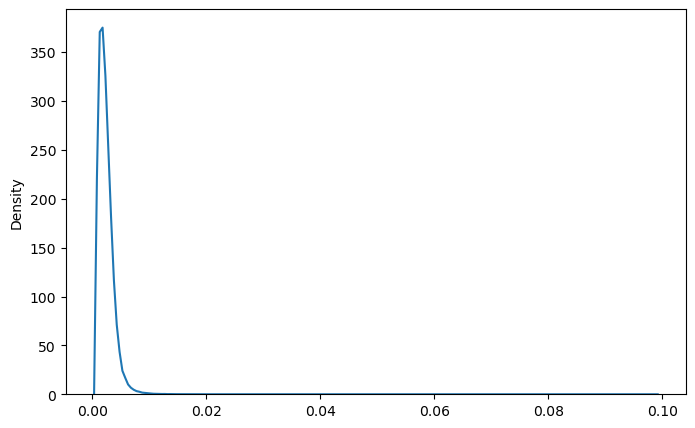

In [36]:
fig = plt.figure(figsize=(8, 5))
sns.kdeplot(pnz)
plt.show()
fig.savefig('tf-dist.png')

In [43]:
gr = groups.set_index('SampleName').loc[:, ['Group']]

In [45]:
pvls = pvals.merge(gr, right_index=True, left_index=True)

In [47]:
pvls_m = pvls.groupby('Group').mean()

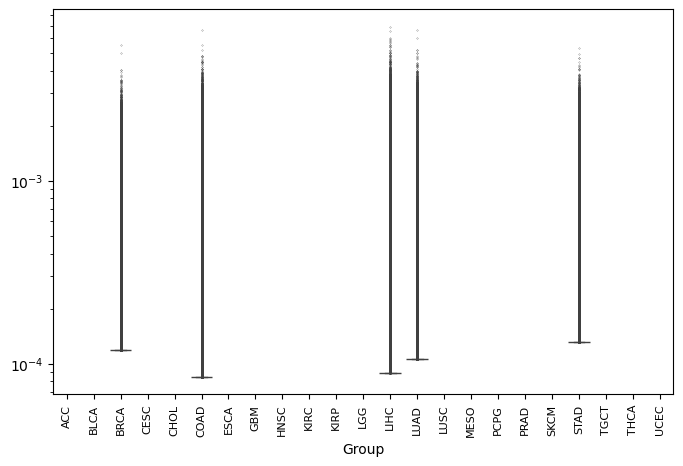

In [52]:
fig = plt.figure(figsize=(8, 5))
sns.boxplot(pvls_m.T, log_scale=True, fliersize=0.2)
plt.xticks(fontsize=8, rotation=90)
plt.show()
fig.savefig('pvls_m.png')

In [23]:
pvals = pvals.set_index('TE')

In [75]:
pvals = pvals.merge(te_meta_.set_index('name'), left_index=True, right_on='name')

In [106]:
rfcls = {n:df for n, df in pvals.groupby('repClass')}

In [101]:
families=pvals['repFamily'].unique()

In [102]:
clss=pvals['repClass'].unique()

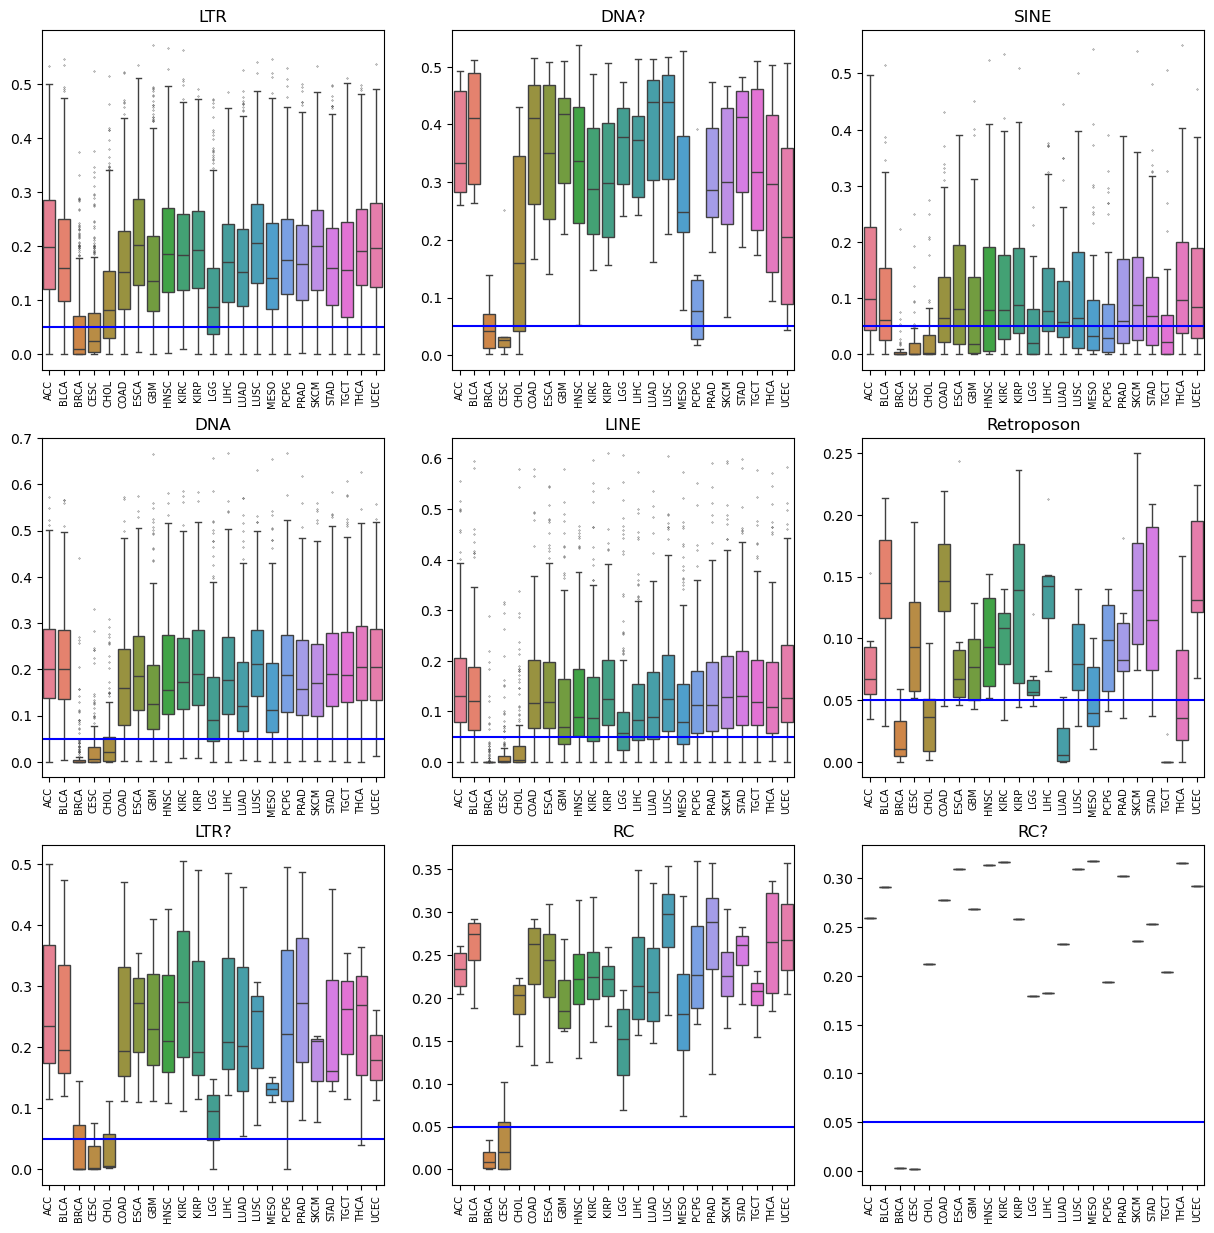

In [117]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
plt.xticks(rotation=90, fontsize=8)
for i, c in enumerate(clss):
    ax = axs.flatten()[i]
    ax.set_title(c)
    sns.boxplot(rfcls[c], fliersize=.3, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=7, rotation=90)  # Adjust fontsize as needed
    ax.axhline(y=0.05, color='blue')

plt.show()

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def apply_pca(df: pd.DataFrame, n_components: int) -> pd.DataFrame:
    """
    Apply PCA to the input DataFrame and return the desired number of components for each sample.

    Parameters:
    df (pd.DataFrame): Input DataFrame with samples as rows and features as columns.
    n_components (int): Number of principal components to return.

    Returns:
    pd.DataFrame: DataFrame with the principal components for each sample.
    """
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(df)
    pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    
    return pca_df

def plot_pca(df: pd.DataFrame, labels: pd.Series):
    """
    Perform PCA on the DataFrame, plot the first two principal components, and color based on the labels.

    Parameters:
    df (pd.DataFrame): Input DataFrame with samples as rows and features as columns.
    labels (pd.Series): Series with labels for each sample.
    """
    # Apply PCA to get the first two components
    pca_df = apply_pca(df, 2)

    # Create a scatter plot
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=labels, cmap='viridis', alpha=0.7)
    
    # Add title and labels
    plt.title('PCA of Dataset')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    
    # Add legend
    legend = plt.legend(*scatter.legend_elements(), title="Classes")
    plt.gca().add_artist(legend)
    
    # Show plot
    plt.show()

# Example usage:
# df = pd.read_csv('your_data.csv')
# labels = pd.Series(['label1', 'label2', ...])  # Replace with your actual labels
# plot_pca(df, labels)
